## Подготовка датасета и двухэтапное обучение Qwen2.5-7B

В этом ноутбуке собран полный воспроизводимый сценарий работы с данными и моделью: от формирования единого Excel-файла датасета до двухэтапного обучения модели `Qwen2.5-7B-Instruct`.

В отличие от исходной структуры проекта, где отдельные этапы были вынесены в разные Python-скрипты и промежуточные файлы, здесь весь процесс организован вокруг одного рабочего Excel-файла. Такой формат удобен для дипломной работы: код, пояснения и логика эксперимента находятся в одном месте и читаются как единая исследовательская история.

В рамках эксперимента используются два этапа обучения:

1. `SFT` на задаче аннотации качества перевода, где модель по исходному тексту и переводу должна выдать краткий вердикт вида `Translation is correct` или `Error: ...`.
2. `DPO` на preference-парах, где `chosen` представляет эталонный перевод, а `rejected` содержит исходный машинный перевод.


## Порядок запуска

Ноутбук рассчитан на обычный последовательный запуск сверху вниз. В Google Colab достаточно открыть `Runtime` и выполнить `Run all` на совместимом `NVIDIA A!))` runtime.

Ниже используется та же логика установки библиотек, что и в рабочих ноутбуках `Unsloth`: сначала Colab-совместимая установка зависимостей, затем обычное выполнение всех последующих ячеек без отдельного restart-блока.

## Установка и логин в Hugging Face


На данном этапе выполняется настройка среды для дообучения модели с использованием библиотеки `Unsloth`, оптимизированной для ускоренного LoRA- и QLoRA-обучения. Дополнительно подготавливаются библиотеки для работы с Excel-файлом, автоматической аннотацией, публикацией артефактов в Hugging Face Hub и последующего benchmark на `BOUQuET`.

Установка оформлена в том же стиле, что и в официальных ноутбуках `Unsloth` для Google Colab: без принудительного restart runtime и без ручного управления CUDA-библиотеками внутри следующих ячеек.

In [ ]:
%%capture
import os
import re

if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer openpyxl scikit-learn pandas sacrebleu matplotlib requests httpx
else:
    import torch
    v = re.match(r"[\d]{1,}\.[\d]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + {"2.10": "0.0.34", "2.9": "0.0.33.post1", "2.8": "0.0.32.post2"}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer openpyxl scikit-learn pandas sacrebleu matplotlib requests httpx
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

import transformers
import trl
import torch
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("TRL:", trl.__version__)
print("Установка завершена. Можно продолжать выполнение ноутбука без отдельного restart runtime.")


## Настройка проекта и рабочего Excel-файла

После перезапуска среды ноутбук переходит к основной логике эксперимента. Ниже задаются рабочая директория, имя листа Excel-файла, флаги повторной пересборки датасета и базовые параметры разбиения выборки.

Если `translation_quality_dataset.xlsx` уже загружен заранее, ноутбук сможет использовать его как основной артефакт и пропустить повторное построение исходной таблицы.

In [ ]:
from pathlib import Path
from types import SimpleNamespace

import pandas as pd


BASE_DIR = Path.cwd()
SHEET_NAME = "examples"
DATASET_WORKBOOK = BASE_DIR / "translation_quality_dataset.xlsx"
OPENAI_MODEL = "gpt-4.1-mini"

WORKBOOK_WAS_PRESENT_AT_START = DATASET_WORKBOOK.exists()
FORCE_REBUILD_DATASET = False
FORCE_OPENAI_REVIEW = False
REQUIRED_WORKBOOK_COLUMNS = {"dpo_rejected"}

SPLIT_RANDOM_STATE = 42
BALANCE_SFT_TRAIN = True
BALANCE_SFT_RANDOM_STATE = 42

pd.set_option("display.max_colwidth", 160)
print(f"Рабочая папка: {BASE_DIR}")
print(f"Основной Excel-файл датасета: {DATASET_WORKBOOK}")
print(f"Файл датасета найден при старте: {WORKBOOK_WAS_PRESENT_AT_START}")
print(f"BALANCE_SFT_TRAIN = {BALANCE_SFT_TRAIN}")

if WORKBOOK_WAS_PRESENT_AT_START and not FORCE_REBUILD_DATASET:
    try:
        workbook_columns = set(pd.read_excel(DATASET_WORKBOOK, sheet_name=SHEET_NAME, nrows=0).columns)
        missing_workbook_columns = sorted(REQUIRED_WORKBOOK_COLUMNS - workbook_columns)
        if missing_workbook_columns:
            FORCE_REBUILD_DATASET = True
            print("Обнаружен существующий Excel-файл старой схемы. Для полного DPO-датасета он будет автоматически пересобран.")
            print(f"Отсутствуют колонки: {missing_workbook_columns}")
    except Exception as exc:
        print(f"Не удалось проверить схему существующего Excel-файла: {exc}")

if WORKBOOK_WAS_PRESENT_AT_START and not FORCE_REBUILD_DATASET:
    print("Обнаружен существующий Excel-файл. Формирование датасета будет пропущено.")
    print("OpenAI-аннотация также будет пропущена, если только FORCE_OPENAI_REVIEW не установлен в True.")
elif WORKBOOK_WAS_PRESENT_AT_START and FORCE_REBUILD_DATASET:
    print("Обнаружен существующий Excel-файл, но для новой DPO-схемы он будет пересобран заново.")
else:
    print("На старте файл не найден. Ноутбук сформирует датасет и при необходимости запустит OpenAI-аннотацию.")


Рабочая папка: /content
Основной Excel-файл датасета: /content/translation_quality_dataset.xlsx
Файл датасета найден при старте: False
BALANCE_SFT_TRAIN = True
На старте файл не найден. Ноутбук сформирует датасет и при необходимости запустит OpenAI-аннотацию.


## Формирование исходного датасета

На первом этапе формируется единый набор примеров из нескольких открытых корпусов оценки качества перевода. Для этого используются корпуса `ACES`, `MLQE-PE` и `WMT MQM`, содержащие как корректные переводы, так и переводы с различными типами ошибок.

Из каждого источника отбираются как положительные, так и отрицательные примеры. В результате формируется сбалансированная выборка, которая затем сохраняется в один Excel-файл и используется на всех следующих стадиях работы.

Если файл `translation_quality_dataset.xlsx` уже был заранее загружен вручную, например в `/content` в Google Colab, этот этап можно не выполнять повторно. В таком случае ноутбук использует уже существующий Excel-файл как основной источник данных.

In [ ]:
from __future__ import annotations

import io
import tarfile
import urllib.request
from pathlib import Path

import pandas as pd
from datasets import load_dataset


OUTPUT_PATH = Path("data/translation_quality_examples_500.xlsx")
SEED = 42
TOTAL_PER_LABEL = 250
PER_DATASET = {
    "ACES": 84,
    "MLQE-PE": 83,
    "WMT MQM": 83,
}


def sample_aces() -> pd.DataFrame:
    ds = load_dataset("nikitam/ACES", "ACES")["train"].to_pandas()

    good = (
        ds[["source", "good-translation", "incorrect-translation", "reference", "phenomena", "langpair"]]
        .rename(
            columns={
                "good-translation": "translation",
                "incorrect-translation": "dpo_rejected",
            }
        )
        .assign(
            dataset="ACES",
            label="good",
            variant="good-translation",
            quality_signal_name="phenomena",
            quality_signal=ds["phenomena"],
        )
    )

    bad = (
        ds[["source", "incorrect-translation", "reference", "phenomena", "langpair"]]
        .rename(columns={"incorrect-translation": "translation"})
        .assign(
            dpo_rejected=lambda x: x["translation"],
            dataset="ACES",
            label="bad",
            variant="incorrect-translation",
            quality_signal_name="phenomena",
            quality_signal=ds["phenomena"],
        )
    )

    frames = [
        good.sample(n=PER_DATASET["ACES"], random_state=SEED).copy(),
        bad.sample(n=PER_DATASET["ACES"], random_state=SEED).copy(),
    ]
    return pd.concat(frames, ignore_index=True)


def _download_tar(repo_path: str) -> tarfile.TarFile:
    url = f"https://raw.githubusercontent.com/sheffieldnlp/mlqe-pe/master/{repo_path}"
    with urllib.request.urlopen(url, timeout=180) as response:
        data = response.read()
    return tarfile.open(fileobj=io.BytesIO(data), mode="r:gz")


def _read_tar_lines(tf: tarfile.TarFile, name: str) -> list[str]:
    with tf.extractfile(name) as file_obj:
        raw = file_obj.read().decode("utf-8", "ignore")
    return [line.rstrip("\n") for line in raw.splitlines()]


def sample_mlqe() -> pd.DataFrame:
    langpairs = ["en-de", "en-zh", "et-en", "ne-en", "ro-en", "ru-en", "si-en"]
    rows: list[dict[str, object]] = []

    for langpair in langpairs:
        repo_path = f"data/post-editing/train/{langpair}-train.tar.gz"
        with _download_tar(repo_path) as tf:
            src = _read_tar_lines(tf, f"{langpair}-train/train.src")
            mt = _read_tar_lines(tf, f"{langpair}-train/train.mt")
            pe = _read_tar_lines(tf, f"{langpair}-train/train.pe")
            hter = _read_tar_lines(tf, f"{langpair}-train/train.hter")

        if not (len(src) == len(mt) == len(pe) == len(hter)):
            raise ValueError(f"Несовпадающие длины MLQE для {langpair}")

        for source, mt_text, pe_text, hter_value in zip(src, mt, pe, hter):
            rows.append(
                {
                    "dataset": "MLQE-PE",
                    "langpair": langpair,
                    "source": source,
                    "mt": mt_text,
                    "pe": pe_text,
                    "reference": pe_text,
                    "hter": float(hter_value),
                }
            )

    df = pd.DataFrame(rows)
    good = (
        df[df["hter"] <= 0.10][["source", "pe", "reference", "langpair", "hter", "mt"]]
        .rename(columns={"pe": "translation", "mt": "dpo_rejected"})
        .assign(
            dataset="MLQE-PE",
            label="good",
            variant="post-edit",
            quality_signal_name="hter",
            quality_signal=lambda x: x["hter"],
        )
    )
    bad = (
        df[df["hter"] >= 0.60][["source", "mt", "reference", "langpair", "hter"]]
        .rename(columns={"mt": "translation"})
        .assign(
            dpo_rejected=lambda x: x["translation"],
            dataset="MLQE-PE",
            label="bad",
            variant="machine-translation",
            quality_signal_name="hter",
            quality_signal=lambda x: x["hter"],
        )
    )

    frames = [
        good.sample(n=PER_DATASET["MLQE-PE"], random_state=SEED).copy(),
        bad.sample(n=PER_DATASET["MLQE-PE"], random_state=SEED).copy(),
    ]
    return pd.concat(frames, ignore_index=True)


def sample_wmt_mqm() -> pd.DataFrame:
    df = load_dataset("RicardoRei/wmt-mqm-human-evaluation")["train"].to_pandas()
    df = df[~df["system"].str.contains("ref", case=False, na=False)].copy()

    good = (
        df[df["score"] >= 95][["src", "mt", "ref", "lp", "score", "system", "domain", "year"]]
        .rename(columns={"src": "source", "mt": "translation", "ref": "reference", "lp": "langpair"})
        .assign(
            dpo_rejected=lambda x: x["translation"],
            dataset="WMT MQM",
            label="good",
            variant="high-score-mt",
            quality_signal_name="mqm_score",
            quality_signal=lambda x: x["score"],
        )
    )
    bad = (
        df[df["score"] <= -25][["src", "mt", "ref", "lp", "score", "system", "domain", "year"]]
        .rename(columns={"src": "source", "mt": "translation", "ref": "reference", "lp": "langpair"})
        .assign(
            dpo_rejected=lambda x: x["translation"],
            dataset="WMT MQM",
            label="bad",
            variant="low-score-mt",
            quality_signal_name="mqm_score",
            quality_signal=lambda x: x["score"],
        )
    )

    frames = [
        good.sample(n=PER_DATASET["WMT MQM"], random_state=SEED).copy(),
        bad.sample(n=PER_DATASET["WMT MQM"], random_state=SEED).copy(),
    ]
    return pd.concat(frames, ignore_index=True)


def build_dataset() -> pd.DataFrame:
    frames = [sample_aces(), sample_mlqe(), sample_wmt_mqm()]
    df = pd.concat(frames, ignore_index=True)
    df = df[
        [
            "dataset",
            "label",
            "variant",
            "langpair",
            "source",
            "translation",
            "dpo_rejected",
            "reference",
            "quality_signal_name",
            "quality_signal",
        ]
    ].copy()
    df.insert(0, "id", range(1, len(df) + 1))
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    df["id"] = range(1, len(df) + 1)
    return df


def main() -> None:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    df = build_dataset()

    label_counts = df["label"].value_counts().to_dict()
    if len(df) != TOTAL_PER_LABEL * 2:
        raise ValueError(f"Ожидалось 500 строк, получено {len(df)}")
    if label_counts.get("good") != TOTAL_PER_LABEL or label_counts.get("bad") != TOTAL_PER_LABEL:
        raise ValueError(f"Неожиданный баланс меток: {label_counts}")

    with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name="examples", index=False)

    print(f"Сохранено {len(df)} строк в {OUTPUT_PATH}")
    print(df["dataset"].value_counts().to_string())
    print(df["label"].value_counts().to_string())


In [ ]:
if WORKBOOK_WAS_PRESENT_AT_START and not FORCE_REBUILD_DATASET:
    sampled_df = pd.read_excel(DATASET_WORKBOOK, dtype=str).fillna("")
    print(f"Используется существующий Excel-файл без пересборки: {DATASET_WORKBOOK}")
else:
    sampled_df = build_dataset()
    with pd.ExcelWriter(DATASET_WORKBOOK, engine="openpyxl") as writer:
        sampled_df.to_excel(writer, sheet_name=SHEET_NAME, index=False)
    print(f"Сформирован исходный датасет: {len(sampled_df)} строк")
    if "dataset" in sampled_df.columns:
        print(sampled_df["dataset"].value_counts().to_string())
    if "label" in sampled_df.columns:
        print(sampled_df["label"].value_counts().to_string())

sampled_df.head()

README.md: 0.00B [00:00, ?B/s]

challenge_set.jsonl:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36476 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/77.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/150347 [00:00<?, ? examples/s]

Сформирован исходный датасет: 500 строк
dataset
ACES       168
WMT MQM    166
MLQE-PE    166
label
good    250
bad     250


,id,dataset,label,variant,langpair,source,translation,dpo_rejected,reference,quality_signal_name,quality_signal
0,1,WMT MQM,good,high-score-mt,en-ru,"""We suggest the government considers lifting the quarantine rules for flights to and from certain regions with lower infection rates, or to places such as t...",«Мы предлагаем правительству повести вопрос об отмене карантинных правил для полетов в и из определенных регионов с более низким уровнем заражения или в так...,«Мы предлагаем правительству повести вопрос об отмене карантинных правил для полетов в и из определенных регионов с более низким уровнем заражения или в так...,"""Чтобы избежать большего ущерба для отраслей въездного и выездного туризма в Соединенном Королевстве, мы предлагаем правительству рассмотреть возможность от...",mqm_score,100.0
1,2,ACES,good,good-translation,ko-fr,1922년 John Henry Kilbuck은 알라스카주 Akiak에서 사망했으며 Edith는 1933년에 사망했습니다.,"En 1922, John Henry Kilbuck meurt à Akiak, en Alaska et Edith en 1933.","Edith est mort en 1922 à Akiak, en Alaska. John Henry Kilbuck est mort en 1933.","En 1922, John Henry Kilbuck mourut à Akiak, en Alaska et Edith en 1933.",phenomena,lexical-overlap
2,3,WMT MQM,good,high-score-mt,en-ru,"The BBC's Guy Hedgecoe in Madrid says contagion among young people is a particular worry, as they have been gathering in large numbers in cities at night.","Корреспондент Би-би-си в Мадриде Гай Хеджкоу говорит, что особое беспокойство вызывает заражение среди молодых людей, поскольку они собираются в больших кол...","Корреспондент Би-би-си в Мадриде Гай Хеджкоу говорит, что особое беспокойство вызывает заражение среди молодых людей, поскольку они собираются в больших кол...","Корреспондент Би-би-си в Мадриде Гай Хеджкоу сообщает, что особое беспокойство вызывают заражения среди молодых людей, которые собираются большими компаниям...",mqm_score,100.0
3,4,ACES,bad,incorrect-translation,ko-fr,"""1961년, Herbert는 """"This Is Your Life""""라는 TV 프로그램의 주제였으며 Eamonn Andrews가 놀라게 만드는 대상이었습니다.""","""Heerbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" en 1961 quand il fut surpris par Eamonn Andrews.""","""Heerbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" en 1961 quand il fut surpris par Eamonn Andrews.""","""En 1961, Herbert Herbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" quand il fut surpris par Eamonn Andrews.""",phenomena,hallucination-named-entity-level-1
4,5,ACES,bad,incorrect-translation,fr-en,L'éditeur a arrêté la concierge.,The editor stopped the male janitor.,The editor stopped the male janitor.,The editor stopped the janitor.,phenomena,ambiguous-translation-wrong-gender-female-anti


## Автоматическая аннотация качества перевода

После формирования исходной выборки выполняется автоматическая разметка столбца `reviewed_verdict` с помощью OpenAI-модели. На вход модели подаются языковая пара, исходный текст, анализируемый перевод и, при наличии, эталонный перевод как вспомогательный ориентир.

Важно, что аннотация выполняется сразу на английском языке. Благодаря этому не требуется отдельный этап последующего перевода вердиктов, а итоговый столбец можно напрямую использовать как целевой ответ для instruction-tuning.

Все изменения записываются в тот же Excel-файл `translation_quality_dataset.xlsx`, поэтому весь датасет на протяжении подготовки остаётся сосредоточен в одном артефакте.

Если Excel-файл был загружен вручную заранее и уже содержит нужные столбцы, OpenAI-аннотацию можно пропустить. В ноутбуке ниже это делается автоматически, если файл существовал уже в момент запуска первой служебной ячейки.

In [ ]:
from __future__ import annotations

import argparse
import json
import os
import re
import shutil
import sys
import time
import unicodedata
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path

import httpx
from openpyxl import load_workbook


SYSTEM_PROMPT = """You are a strict translation quality reviewer.

Compare the source text with the translation. Use the reference translation only as a helper.

Return JSON only.

Allowed outputs:
{"verdict":"correct"}
{"verdict":"error","description":"<short English description>"}

Rules:
- If the translation preserves the meaning and is acceptable, use {"verdict":"correct"}.
- Otherwise use {"verdict":"error","description":"..."}.
- The description must be short, specific, and in English.
- Focus on the main issue only.
- Ignore minor stylistic differences when meaning is preserved.
- Judge the translation, not the reference.
- Do not add markdown, explanations, or extra keys.
"""


FALLBACK_LABEL_DESCRIPTIONS = {
    "wrong meaning": "wrong meaning",
    "omission": "omission of meaning",
    "addition": "added unsupported meaning",
    "named entity error": "named entity error",
    "gender or number error": "gender or number error",
    "grammar or fluency error": "grammar or fluency error",
    "word choice error": "word choice error",
    "translation error": "translation error",
}


@dataclass(frozen=True)
class ReviewTask:
    row_idx: int
    source: str
    translation: str
    reference: str
    langpair: str


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Review translation examples in Excel with OpenAI GPT.")
    parser.add_argument(
        "--input",
        default="data/translation_quality_examples_500_reviewed.xlsx",
        help="Path to the Excel file that should be updated in place.",
    )
    parser.add_argument(
        "--sheet",
        default="examples",
        help="Worksheet name.",
    )
    parser.add_argument(
        "--model",
        default="gpt-4.1-mini",
        help="OpenAI model name.",
    )
    parser.add_argument(
        "--workers",
        type=int,
        default=5,
        help="Number of concurrent API requests.",
    )
    parser.add_argument(
        "--save-every",
        type=int,
        default=25,
        help="Save workbook progress every N completed rows.",
    )
    parser.add_argument(
        "--limit",
        type=int,
        default=0,
        help="Process only the first N data rows.",
    )
    parser.add_argument(
        "--overwrite",
        action="store_true",
        help="Overwrite existing GPT reviews.",
    )
    parser.add_argument(
        "--backup-suffix",
        default="",
        help="Optional suffix for the backup copy of the workbook. Empty value disables backup creation.",
    )
    return parser.parse_args()


def clean_text(value: object) -> str:
    if value is None:
        return ""
    return str(value).strip()


def safe_status(text: str) -> str:
    encoding = sys.stdout.encoding or "utf-8"
    return text.encode(encoding, errors="replace").decode(encoding)


def ensure_column(ws, header_name: str) -> int:
    headers = [cell.value for cell in ws[1]]
    if header_name in headers:
        return headers.index(header_name) + 1
    col_idx = len(headers) + 1
    ws.cell(row=1, column=col_idx, value=header_name)
    return col_idx


def ensure_backup(path: Path, suffix: str) -> Path:
    if not suffix:
        return path
    backup_path = path.with_name(f"{path.stem}{suffix}")
    if not backup_path.exists():
        backup_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, backup_path)
    return backup_path


def staging_path_for(path: Path) -> Path:
    return path.with_name(f"{path.stem}__gpt_working{path.suffix}")


def save_via_staging(wb, target_path: Path) -> None:
    staging_path = staging_path_for(target_path)
    wb.save(staging_path)
    os.replace(staging_path, target_path)


def strip_code_fences(text: str) -> str:
    compact = text.strip()
    if compact.startswith("```") and compact.endswith("```"):
        lines = compact.splitlines()
        if len(lines) >= 3:
            return "\n".join(lines[1:-1]).strip()
    return compact


def has_cyrillic(text: str) -> bool:
    return any("CYRILLIC" in unicodedata.name(ch, "") for ch in text)


def extract_json_object(text: str) -> dict[str, object] | None:
    compact = strip_code_fences(text)
    candidates = [compact]

    start = compact.find("{")
    end = compact.rfind("}")
    if start != -1 and end != -1 and end > start:
        candidates.append(compact[start : end + 1])

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, dict):
            return parsed
    return None


def normalize_error_description(text: str) -> str:
    compact = " ".join(str(text or "").strip().split())
    compact = re.sub(r"^(error|ошибка)\s*:\s*", "", compact, flags=re.IGNORECASE)
    compact = compact.strip(" .}")
    if not compact:
        return "translation error"
    return compact[0].lower() + compact[1:] if len(compact) > 1 else compact.lower()


def normalize_verdict(raw_text: str) -> str:
    parsed = extract_json_object(raw_text)
    if parsed:
        verdict = str(parsed.get("verdict", "")).strip().lower()
        if verdict == "correct":
            return "Translation is correct"
        if verdict == "error":
            description = normalize_error_description(parsed.get("description", ""))
            return f"Error: {description}"

    compact = " ".join(strip_code_fences(raw_text).split())
    lowered = compact.lower()
    if not compact:
        return "Error: empty model response"
    if "translation is correct" in lowered or lowered in {"correct", "no error", "no errors"}:
        return "Translation is correct"

    match = re.search(r"error\s*:\s*(.+)", compact, flags=re.IGNORECASE)
    if match:
        return f"Error: {normalize_error_description(match.group(1))}"

    for label, description in FALLBACK_LABEL_DESCRIPTIONS.items():
        if label in lowered:
            return f"Error: {description}"

    return f"Error: {normalize_error_description(compact)}"


def build_user_prompt(task: ReviewTask) -> str:
    reference_text = task.reference or "[not provided]"
    langpair_text = task.langpair or "[unknown]"
    return (
        f"Language pair: {langpair_text}\n\n"
        f"Source:\n{task.source}\n\n"
        f"Translation:\n{task.translation}\n\n"
        f"Reference:\n{reference_text}"
    )


def call_openai(*, api_key: str, model: str, task: ReviewTask, max_retries: int = 5) -> str:
    payload = {
        "model": model,
        "response_format": {"type": "json_object"},
        "temperature": 0,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_user_prompt(task)},
        ],
    }
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    last_error = "unknown error"
    for attempt in range(1, max_retries + 1):
        try:
            response = httpx.post(
                "https://api.openai.com/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=90.0,
            )
            if response.status_code in {429, 500, 502, 503, 504}:
                last_error = f"HTTP {response.status_code}: {response.text[:300]}"
                time.sleep(min(20, 2 ** (attempt - 1)))
                continue

            response.raise_for_status()
            body = response.json()
            content = clean_text(body["choices"][0]["message"]["content"])
            verdict = normalize_verdict(content)
            return verdict
        except (httpx.HTTPError, KeyError, ValueError, json.JSONDecodeError) as exc:
            last_error = str(exc)
            if attempt == max_retries:
                break
            time.sleep(min(20, 2 ** (attempt - 1)))

    return f"Error: failed to get model response ({last_error})"


def should_process_row(*, overwrite: bool, current_method: str) -> bool:
    if overwrite:
        return True
    if not current_method:
        return True
    return not current_method.startswith("gpt-openai:")


def build_tasks(ws, header_map: dict[str, int], *, limit: int, overwrite: bool) -> list[ReviewTask]:
    tasks: list[ReviewTask] = []
    for row_idx in range(2, ws.max_row + 1):
        data_index = row_idx - 1
        if limit > 0 and data_index > limit:
            break

        current_method = clean_text(ws.cell(row=row_idx, column=header_map["review_method"]).value)
        if not should_process_row(overwrite=overwrite, current_method=current_method):
            continue

        source = clean_text(ws.cell(row=row_idx, column=header_map["source"]).value)
        translation = clean_text(ws.cell(row=row_idx, column=header_map["translation"]).value)
        reference = clean_text(ws.cell(row=row_idx, column=header_map["reference"]).value)
        langpair = clean_text(ws.cell(row=row_idx, column=header_map["langpair"]).value)

        tasks.append(
            ReviewTask(
                row_idx=row_idx,
                source=source,
                translation=translation,
                reference=reference,
                langpair=langpair,
            )
        )
    return tasks


def preserve_previous_reviews(ws, *, verdict_col: int, method_col: int) -> None:
    previous_verdict_col = ensure_column(ws, "reviewed_verdict_previous")
    previous_method_col = ensure_column(ws, "review_method_previous")

    for row_idx in range(2, ws.max_row + 1):
        old_verdict = ws.cell(row=row_idx, column=verdict_col).value
        old_method = ws.cell(row=row_idx, column=method_col).value
        if ws.cell(row=row_idx, column=previous_verdict_col).value in (None, "") and old_verdict not in (None, ""):
            ws.cell(row=row_idx, column=previous_verdict_col, value=old_verdict)
        if ws.cell(row=row_idx, column=previous_method_col).value in (None, "") and old_method not in (None, ""):
            ws.cell(row=row_idx, column=previous_method_col, value=old_method)


def annotate_workbook(args: argparse.Namespace) -> Path:
    api_key = os.getenv("OPENAI_API_KEY", "").strip()
    if not api_key:
        raise ValueError("Требуется переменная окружения OPENAI_API_KEY")

    input_path = Path(args.input)
    if not input_path.exists():
        raise FileNotFoundError(f"Excel-файл не найден: {input_path}")

    backup_path = ensure_backup(input_path, args.backup_suffix)
    if args.backup_suffix:
        print(safe_status(f"Резервная копия сохранена в {backup_path}"))

    wb = load_workbook(input_path)
    ws = wb[args.sheet]

    header_map = {cell.value: idx + 1 for idx, cell in enumerate(ws[1])}
    required = ["source", "translation", "reference", "langpair"]
    missing = [name for name in required if name not in header_map]
    if missing:
        raise ValueError(f"Отсутствуют обязательные колонки: {', '.join(missing)}")

    verdict_col = ensure_column(ws, "reviewed_verdict")
    method_col = ensure_column(ws, "review_method")
    header_map = {cell.value: idx + 1 for idx, cell in enumerate(ws[1])}

    preserve_previous_reviews(ws, verdict_col=verdict_col, method_col=method_col)

    tasks = build_tasks(ws, header_map, limit=args.limit, overwrite=args.overwrite)
    total = len(tasks)
    print(safe_status(f"Строк к обработке: {total}"))
    if total == 0:
        save_via_staging(wb, input_path)
        wb.close()
        return input_path

    completed = 0
    failures = 0
    review_method = f"gpt-openai:{args.model}"

    with ThreadPoolExecutor(max_workers=max(1, args.workers)) as executor:
        future_map = {
            executor.submit(call_openai, api_key=api_key, model=args.model, task=task): task
            for task in tasks
        }
        for future in as_completed(future_map):
            task = future_map[future]
            verdict = future.result()
            ws.cell(row=task.row_idx, column=verdict_col, value=verdict)
            ws.cell(row=task.row_idx, column=method_col, value=review_method)

            completed += 1
            if verdict.startswith("Error: failed to get model response"):
                failures += 1
            print(safe_status(f"[{completed}/{total}] строка {task.row_idx}: {verdict}"))

            if completed % max(1, args.save_every) == 0:
                save_via_staging(wb, input_path)

    save_via_staging(wb, input_path)
    wb.close()

    if failures:
        print(safe_status(f"Завершено с ошибками вызова модели: {failures}"))
    else:
        print("Завершено без ошибок вызова модели")
    return input_path


def main() -> None:
    args = parse_args()
    output_path = annotate_workbook(args)
    print(f"Размеченный Excel-файл сохранён в {output_path}")


## Получение OpenAI API key в Google Colab

Если ноутбук запускается в Google Colab, ключ `OPENAI_API_KEY` удобно и безопасно загрузить через Colab Secrets. Ниже приведена отдельная ячейка, которая пытается получить ключ из `userdata`, а при отсутствии Colab просто оставляет текущее окружение без изменений.

Эта ячейка нужна только для доступа к OpenAI API на этапе автоматической аннотации столбца `reviewed_verdict`. Если итоговый Excel-файл уже был загружен вручную и аннотацию выполнять не требуется, запускать её необязательно. Если же нужно принудительно запустить аннотацию даже для уже загруженного файла, в первой служебной ячейке следует установить `FORCE_OPENAI_REVIEW = True`.

Параметр `workers` задаёт количество параллельных API-запросов при аннотации. Значение `workers=5` означает, что ноутбук может отправлять до пяти запросов одновременно. Это ускоряет разметку, но при слишком большом значении может увеличить нагрузку на лимиты, квоты и вероятность временных ошибок API. Значение `5` здесь выбрано как умеренный компромисс между скоростью и стабильностью.

In [ ]:
import os

try:
    from google.colab import userdata
    colab_openai_key = userdata.get("OPENAI_API_KEY")
except Exception:
    colab_openai_key = None

if colab_openai_key:
    os.environ["OPENAI_API_KEY"] = colab_openai_key
    print("OPENAI_API_KEY загружен из Colab Secrets.")
else:
    print("Colab Secrets не обнаружены или ключ OPENAI_API_KEY отсутствует. Будет использовано текущее окружение, если ключ уже задан.")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()
print(f"OPENAI_API_KEY задан: {bool(OPENAI_API_KEY)}")

OPENAI_API_KEY загружен из Colab Secrets.
OPENAI_API_KEY задан: True


In [ ]:
review_args = SimpleNamespace(
    input=str(DATASET_WORKBOOK),
    sheet=SHEET_NAME,
    model=OPENAI_MODEL,
    workers=5,
    save_every=25,
    limit=0,
    overwrite=False,
    backup_suffix="",
)

if WORKBOOK_WAS_PRESENT_AT_START and not FORCE_REBUILD_DATASET and not FORCE_OPENAI_REVIEW:
    reviewed_df = pd.read_excel(DATASET_WORKBOOK, dtype=str).fillna("")
    print(f"OpenAI-аннотация пропущена, так как Excel-файл был загружен вручную: {DATASET_WORKBOOK}")
    if "reviewed_verdict" in reviewed_df.columns:
        non_empty_reviews = reviewed_df["reviewed_verdict"].astype(str).str.strip().ne("").sum()
        print(f"Уже заполнено reviewed_verdict строк: {non_empty_reviews}/{len(reviewed_df)}")
    reviewed_df.head()
else:
    annotate_workbook(review_args)
    reviewed_df = pd.read_excel(DATASET_WORKBOOK, dtype=str).fillna("")
    reviewed_df.head()


Строк к обработке: 500
[1/500] строка 4: Translation is correct
[2/500] строка 3: Translation is correct
[3/500] строка 5: Error: the name 'Herbert' is misspelled as 'Heerbert' in the translation
[4/500] строка 2: Error: translation incorrectly renders 'considers lifting' as 'повести вопрос об отмене' which means 'bring up the issue of cancellation', losing the nuance of 'considering' or 'thinking about' lifting the rules
[5/500] строка 6: Error: incorrect gender specification: 'concierge' means 'janitor' without gender, but translation adds 'male'
[6/500] строка 8: Translation is correct
[7/500] строка 7: Translation is correct
[8/500] строка 11: Error: translation incorrectly uses 'он' (he) instead of 'it' for the subject and changes the meaning by stating 'he is too quiet' instead of 'it gets a little too quiet'
[9/500] строка 10: Error: the translation uses formal 'Sie' instead of informal 'du' and awkward phrasing 'eine Menge, die wir versucht haben', which distorts the meaning an

## Подготовка датасета для SFT-обучения Qwen2.5-7B

На данном этапе выполняется подготовка набора данных для последующего supervised fine-tuning модели `Qwen2.5-7B-Instruct`. В качестве исходных данных используется размеченный Excel-файл, содержащий примеры исходного текста, машинного перевода и экспертного вердикта о качестве перевода.

Цель этапа заключается в преобразовании исходной табличной разметки в формат инструкционного обучения, пригодный для дообучения диалоговой языковой модели. Для этого из таблицы формируются пары вида: **инструкция -> вход -> целевой ответ**, где модель должна по исходному тексту и переводу выдать краткий вердикт о корректности перевода.


## Загрузка и валидация исходного датасета

Сначала выполняется загрузка Excel-файла и базовая проверка его структуры. На этом шаге контролируется наличие обязательных колонок: исходного текста, перевода, языковой пары и итогового экспертного вердикта. Дополнительно из датасета удаляются пустые записи, а также формируется бинарный признак `is_error`, который позволяет отделить корректные переводы от переводов с ошибками.

Такой признак далее используется для стратифицированного разбиения выборки на обучающую и валидационную части. Это позволяет сохранить соотношение положительных и отрицательных примеров в обеих подвыборках и уменьшить риск перекоса при обучении модели.


In [ ]:
from sklearn.model_selection import train_test_split


df = pd.read_excel(DATASET_WORKBOOK, dtype=str).fillna("")

required_cols = ["source", "translation", "langpair", "reviewed_verdict"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Отсутствуют колонки: {missing}")

df = df[df["reviewed_verdict"].str.strip() != ""].copy()
df["is_error"] = (df["reviewed_verdict"].str.strip() != "Translation is correct").astype(int)

df.head()


,id,dataset,label,variant,langpair,source,translation,dpo_rejected,reference,quality_signal_name,quality_signal,reviewed_verdict,review_method,reviewed_verdict_previous,review_method_previous,is_error
0,1,WMT MQM,good,high-score-mt,en-ru,"""We suggest the government considers lifting the quarantine rules for flights to and from certain regions with lower infection rates, or to places such as t...",«Мы предлагаем правительству повести вопрос об отмене карантинных правил для полетов в и из определенных регионов с более низким уровнем заражения или в так...,«Мы предлагаем правительству повести вопрос об отмене карантинных правил для полетов в и из определенных регионов с более низким уровнем заражения или в так...,"""Чтобы избежать большего ущерба для отраслей въездного и выездного туризма в Соединенном Королевстве, мы предлагаем правительству рассмотреть возможность от...",mqm_score,100,"Error: translation incorrectly renders 'considers lifting' as 'повести вопрос об отмене' which means 'bring up the issue of cancellation', losing the nuance...",gpt-openai:gpt-4.1-mini,,,1
1,2,ACES,good,good-translation,ko-fr,1922년 John Henry Kilbuck은 알라스카주 Akiak에서 사망했으며 Edith는 1933년에 사망했습니다.,"En 1922, John Henry Kilbuck meurt à Akiak, en Alaska et Edith en 1933.","Edith est mort en 1922 à Akiak, en Alaska. John Henry Kilbuck est mort en 1933.","En 1922, John Henry Kilbuck mourut à Akiak, en Alaska et Edith en 1933.",phenomena,lexical-overlap,Translation is correct,gpt-openai:gpt-4.1-mini,,,0
2,3,WMT MQM,good,high-score-mt,en-ru,"The BBC's Guy Hedgecoe in Madrid says contagion among young people is a particular worry, as they have been gathering in large numbers in cities at night.","Корреспондент Би-би-си в Мадриде Гай Хеджкоу говорит, что особое беспокойство вызывает заражение среди молодых людей, поскольку они собираются в больших кол...","Корреспондент Би-би-си в Мадриде Гай Хеджкоу говорит, что особое беспокойство вызывает заражение среди молодых людей, поскольку они собираются в больших кол...","Корреспондент Би-би-си в Мадриде Гай Хеджкоу сообщает, что особое беспокойство вызывают заражения среди молодых людей, которые собираются большими компаниям...",mqm_score,100,Translation is correct,gpt-openai:gpt-4.1-mini,,,0
3,4,ACES,bad,incorrect-translation,ko-fr,"""1961년, Herbert는 """"This Is Your Life""""라는 TV 프로그램의 주제였으며 Eamonn Andrews가 놀라게 만드는 대상이었습니다.""","""Heerbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" en 1961 quand il fut surpris par Eamonn Andrews.""","""Heerbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" en 1961 quand il fut surpris par Eamonn Andrews.""","""En 1961, Herbert Herbert fut le sujet d'un programme télévisé de """"This Is Your Life"""" quand il fut surpris par Eamonn Andrews.""",phenomena,hallucination-named-entity-level-1,Error: the name 'Herbert' is misspelled as 'Heerbert' in the translation,gpt-openai:gpt-4.1-mini,,,1
4,5,ACES,bad,incorrect-translation,fr-en,L'éditeur a arrêté la concierge.,The editor stopped the male janitor.,The editor stopped the male janitor.,The editor stopped the janitor.,phenomena,ambiguous-translation-wrong-gender-female-anti,"Error: incorrect gender specification: 'concierge' means 'janitor' without gender, but translation adds 'male'",gpt-openai:gpt-4.1-mini,,,1


## Формирование обучающих примеров для SFT

На данном этапе каждая строка датасета преобразуется в пример инструкционного обучения. Модель получает языковую пару, исходный текст и перевод, который необходимо оценить, а в качестве целевого ответа используется значение из столбца `reviewed_verdict`.

После этого датасет разделяется на обучающую и валидационную выборки в пропорции `90/10` со стратификацией по признаку `is_error`. Если получившаяся обучающая выборка оказывается несбалансированной, в ноутбуке может быть дополнительно включена балансировка `SFT train` за счёт oversampling: меньший класс увеличивается до размера большего класса. Валидационная выборка при этом остаётся без изменений, чтобы итоговая оценка оставалась ближе к исходному распределению данных.

In [ ]:
SFT_INSTRUCTION = (
    "You are a professional translation QA specialist. "
    "Analyze the translation against the source text. "
    "Reply with exactly one verdict: "
    "'Translation is correct' or 'Error: <short description>'."
)


def build_sft_input(row):
    return (
        f"Language pair: {row['langpair']}\n"
        f"Source text:\n{row['source']}\n\n"
        f"Translation to analyze:\n{row['translation']}"
    )


def oversample_minority_class(train_df, label_col="is_error", random_state=42):
    class_counts = train_df[label_col].value_counts()
    if len(class_counts) <= 1:
        return train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    target_size = int(class_counts.max())
    balanced_parts = []
    for _, part_df in train_df.groupby(label_col, sort=True):
        replace = len(part_df) < target_size
        sampled_part = part_df.sample(
            n=target_size,
            replace=replace,
            random_state=random_state,
        )
        balanced_parts.append(sampled_part)

    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df


df["instruction"] = SFT_INSTRUCTION
df["input"] = df.apply(build_sft_input, axis=1)
df["output"] = df["reviewed_verdict"].str.strip()

sft_train_df, sft_eval_df = train_test_split(
    df[["instruction", "input", "output", "is_error"]],
    test_size=0.10,
    random_state=SPLIT_RANDOM_STATE,
    stratify=df["is_error"],
)

sft_train_before_balance_df = sft_train_df.copy()
train_counts_before = sft_train_before_balance_df["is_error"].value_counts().sort_index().to_dict()

if BALANCE_SFT_TRAIN:
    sft_train_df = oversample_minority_class(
        sft_train_df,
        label_col="is_error",
        random_state=BALANCE_SFT_RANDOM_STATE,
    )

train_counts_after = sft_train_df["is_error"].value_counts().sort_index().to_dict()

sft_train_data = sft_train_df[["instruction", "input", "output"]].to_dict(orient="records")
sft_eval_data = sft_eval_df[["instruction", "input", "output"]].to_dict(orient="records")

print(f"SFT обучение: {len(sft_train_data)} | SFT валидация: {len(sft_eval_data)}")
print("Распределение train до балансировки:", train_counts_before)
print("Распределение train после балансировки:", train_counts_after)
print("Доля ошибок в train:", round(sft_train_df["is_error"].mean(), 3))
print("Доля ошибок в eval:", round(sft_eval_df["is_error"].mean(), 3))

sft_train_df.head()

SFT обучение: 570 | SFT валидация: 50
Распределение train до балансировки: {0: 165, 1: 285}
Распределение train после балансировки: {0: 285, 1: 285}
Доля ошибок в train: 0.5
Доля ошибок в eval: 0.64


,instruction,input,output,is_error
0,You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' ...,"Language pair: en-ru\nSource text:\nNow that many have tried it with good results, remote work might be here to stay.\n\nTranslation to analyze:\nТеперь, ко...","Error: incorrect use of 'могла бы' (conditional) instead of 'может' (indicative), changing the meaning from possibility to conditional mood",1
1,You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' ...,"Language pair: en-de\nSource text:\nPitchfork complimented the vocals but criticized the "" dated "" sound .\n\nTranslation to analyze:\nPitchfork lobte den G...",Translation is correct,0
2,You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' ...,Language pair: ru-en\nSource text:\nВот непосредственно заявление со ссылками на нарушенный закон .\n\nTranslation to analyze:\nHere is a direct statement w...,Translation is correct,0
3,You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' ...,"Language pair: en-de\nSource text:\n""And finally, after four full hours of my lying and staring at it, the phone rang, and somehow I managed to pick it up, ...",Error: incorrect pronoun 'sie' instead of 'er' for 'mein Vater' and unnatural phrasing 'es abzuholen' instead of 'dranzugehen' or 'abheben' for answering th...,1
4,You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' ...,"Language pair: en-de\nSource text:\nGenerally aloof , Smerdyakov admires Ivan and shares his atheism .\n\nTranslation to analyze:\nGenerell bewundert Smerdy...","Error: translation omits 'aloof', changing the meaning",1


## Приведение данных к формату диалоговой модели Qwen

Так как дальнейшее обучение выполняется для модели `Qwen2.5-7B-Instruct`, подготовленные примеры необходимо привести к формату диалогового взаимодействия. Для этого используется токенизатор модели и метод `apply_chat_template`, который автоматически преобразует пары `user/assistant` во внутренний текстовый шаблон.

Ниже используется тот же базовый стиль загрузки модели, что и в рабочих ноутбуках `Unsloth`: стандартный импорт `Unsloth`, автоматический выбор `dtype` и загрузка модели в `4-bit`-режиме для экономии памяти на `Tesla T4`.

In [ ]:
import os

import torch
from datasets import Dataset

import unsloth
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

from trl import SFTConfig, SFTTrainer


os.environ["WANDB_DISABLED"] = "true"
os.environ["WAND_DISABLE_SERVICE"] = "true"

dtype = None
USE_4BIT_LOADING = True
SFT_OPTIMIZER = "adamw_8bit"
SFT_TRAIN_BATCH_SIZE = 1
SFT_EVAL_BATCH_SIZE = 1
SFT_GRADIENT_ACCUMULATION_STEPS = 16

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-7B-Instruct",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=USE_4BIT_LOADING,
)

tokenizer.eos_token = "<|im_end|>"
if tokenizer.pad_token in (None, "<EOS_TOKEN>"):
    tokenizer.pad_token = tokenizer.eos_token


def format_qwen25_example(example):
    messages = [
        {"role": "user", "content": f"{example['instruction']}\n\n{example['input']}"},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    ).rstrip()
    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token
    return {"text": text}


train_dataset = Dataset.from_list(sft_train_data).map(format_qwen25_example)
eval_dataset = Dataset.from_list(sft_eval_data).map(format_qwen25_example)

print(f"Режим загрузки 4-bit: {USE_4BIT_LOADING}")
print(f"Оптимизатор SFT: {SFT_OPTIMIZER}")
print("Модель и токенизатор успешно загружены")

train_dataset[0]


/tmp/ipykernel_4913/3181843304.py:6: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  import unsloth


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Map:   0%|          | 0/570 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Режим загрузки 4-bit: True
Оптимизатор SFT: adamw_8bit
Модель и токенизатор успешно загружены


{'instruction': "You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' or 'Error: <short description>'.",
 'input': 'Language pair: en-ru\nSource text:\nNow that many have tried it with good results, remote work might be here to stay.\n\nTranslation to analyze:\nТеперь, когда многие попробовали это с хорошими результатами, удаленная работа могла бы остаться здесь.',
 'output': "Error: incorrect use of 'могла бы' (conditional) instead of 'может' (indicative), changing the meaning from possibility to conditional mood",
 'text': "<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nYou are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' or 'Error: <short description>'.\n\nLanguage pair: en-ru\nSource text:\nNow that many have 

## Результат подготовки

В результате был сформирован компактный SFT-датасет для обучения модели `Qwen2.5-7B-Instruct` на задаче автоматической оценки качества перевода. Исходные табличные данные были преобразованы в формат инструкционного обучения, разделены на обучающую и валидационную выборки и приведены к внутреннему шаблону диалоговой модели.

Подготовленный набор данных может быть напрямую использован на следующем этапе работы для supervised fine-tuning модели, а также для последующей количественной и качественной оценки результатов дообучения.


Для повышения качества instruction-tuning используется режим `train_on_responses_only`, при котором функция потерь вычисляется только по ответу ассистента. Это позволяет исключить из оптимизации токены пользовательского запроса и сосредоточить обучение модели на генерации корректного итогового вердикта. В результате модель учится не воспроизводить входной текст, а формировать правильный ответ на его основе.


In [ ]:
if tokenizer.eos_token in (None, "<EOS_TOKEN>"):
    tokenizer.eos_token = "<|im_end|>"
if tokenizer.pad_token in (None, "<EOS_TOKEN>"):
    tokenizer.pad_token = tokenizer.eos_token

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

sft_trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        dataset_text_field="text",
        max_length=max_seq_length,
        eos_token="<|im_end|>",
        pad_token="<|im_end|>",
        per_device_train_batch_size=SFT_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=SFT_GRADIENT_ACCUMULATION_STEPS,
        per_device_eval_batch_size=SFT_EVAL_BATCH_SIZE,
        num_train_epochs=3,
        learning_rate=1e-4,
        warmup_ratio=0.03,
        lr_scheduler_type="linear",
        weight_decay=0.01,
        logging_steps=5,
        eval_strategy="steps",
        eval_steps=10,
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        output_dir="sft_outputs",
        optim=SFT_OPTIMIZER,
        seed=3407,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        report_to="none",
        packing=False,
    ),
)

sft_trainer = train_on_responses_only(
    sft_trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)

sft_trainer.train()
model.save_pretrained("sft_lora_model")
tokenizer.save_pretrained("sft_lora_model")


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/570 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=16):   0%|          | 0/570 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/570 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
10,1.443200,0.828682
20,0.883100,0.697632
30,0.775500,0.693892
40,0.748200,0.654894
50,0.562000,0.638771
60,0.642400,0.679598
70,0.654500,0.691916
80,0.602100,0.664322
90,0.432100,0.678337
100,0.470900,0.712011


('sft_lora_model/tokenizer_config.json',
 'sft_lora_model/special_tokens_map.json',
 'sft_lora_model/chat_template.jinja',
 'sft_lora_model/vocab.json',
 'sft_lora_model/merges.txt',
 'sft_lora_model/added_tokens.json',
 'sft_lora_model/tokenizer.json')

## Быстрая проверка SFT-модели

После завершения первого этапа обучения полезно проверить, что модель действительно научилась выдавать краткий QA-вердикт в нужном формате. Для этого ниже выполняется короткий инференс на простом примере.


In [ ]:
from unsloth import FastLanguageModel


FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "user",
        "content": (
            "You are a professional translation QA specialist. "
            "Analyze the translation against the source text. "
            "Reply with exactly one verdict: "
            "'Translation is correct' or 'Error: <short description>'.\n\n"
            "Language pair: en-ru\n"
            "Source text:\nThe cat is sleeping on the sofa.\n\n"
            "Translation to analyze:\nКошка спит на диване."
        ),
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

input_device = next(model.parameters()).device
inputs = tokenizer([text], return_tensors="pt")
inputs = {key: value.to(input_device) for key, value in inputs.items()}
outputs = model.generate(**inputs, max_new_tokens=64, use_cache=True)
print(tokenizer.batch_decode(outputs, skip_special_tokens=False)[0])


<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You are a professional translation QA specialist. Analyze the translation against the source text. Reply with exactly one verdict: 'Translation is correct' or 'Error: <short description>'.

Language pair: en-ru
Source text:
The cat is sleeping on the sofa.

Translation to analyze:
Кошка спит на диване.<|im_end|>
<|im_start|>assistant
Translation is correct<|im_end|>


## Подготовка preference-датасета для DPO-обучения

Второй этап обучения строится по другой логике. Если на стадии SFT модель учится диагностировать качество перевода и формулировать краткую аннотацию ошибки, то на стадии DPO она получает сигнал предпочтения между двумя вариантами перевода.

Для каждой строки полного Excel-датасета формируется тройка вида `prompt -> chosen -> rejected`. В качестве `chosen` используется эталонный перевод, а в качестве `rejected` — некорректный перевод, если он явно доступен в столбце `dpo_rejected`; в противном случае берётся текущий перевод из столбца `translation`. Благодаря этому DPO-этап использует весь датасет из `500` строк, а не только подмножество ошибочных примеров.


In [ ]:
dpo_df = pd.read_excel(DATASET_WORKBOOK, dtype=str).fillna("")

if "dpo_rejected" not in dpo_df.columns:
    dpo_df["dpo_rejected"] = ""

dpo_df["reference"] = dpo_df["reference"].astype(str).str.strip()
dpo_df["translation"] = dpo_df["translation"].astype(str).str.strip()
dpo_df["dpo_rejected"] = dpo_df["dpo_rejected"].astype(str).str.strip()

dpo_df = dpo_df[dpo_df["reference"] != ""].copy()

DPO_INSTRUCTION = (
    "You are a professional translator. Produce the best possible translation for the given source text."
)


def build_dpo_prompt(row):
    return (
        f"{DPO_INSTRUCTION}\n\n"
        f"Language pair: {row['langpair']}\n"
        f"Source text:\n{row['source']}"
    )


dpo_df["prompt"] = dpo_df.apply(build_dpo_prompt, axis=1)
dpo_df["chosen"] = dpo_df["reference"]
dpo_df["rejected"] = dpo_df["dpo_rejected"].where(
    dpo_df["dpo_rejected"] != "",
    dpo_df["translation"],
)
dpo_df = dpo_df[dpo_df["rejected"] != ""].copy()

dpo_train_df, dpo_eval_df = train_test_split(
    dpo_df[["prompt", "chosen", "rejected"]],
    test_size=0.10,
    random_state=42,
)

dpo_train_data = dpo_train_df.to_dict(orient="records")
dpo_eval_data = dpo_eval_df.to_dict(orient="records")

print(f"DPO всего: {len(dpo_df)} | DPO обучение: {len(dpo_train_data)} | DPO валидация: {len(dpo_eval_data)}")
if len(dpo_df) < 500:
    print("Внимание: DPO-набор меньше 500 строк. Если используется старый Excel-файл, установите FORCE_REBUILD_DATASET = True и пересоберите workbook.")
dpo_train_df.head()


DPO всего: 500 | DPO обучение: 450 | DPO валидация: 50


,prompt,chosen,rejected
72,You are a professional translator. Produce the best possible translation for the given source text.\n\nLanguage pair: et-en\nSource text:\nMagnaadid ise või...,The magnates themselves or clans of magnates formed groups or factions with shared regional or other interests .,It was the groupings or political groups with common regional or other interests that were formed by the musicians themselves or by the magnavians .
182,You are a professional translator. Produce the best possible translation for the given source text.\n\nLanguage pair: en-ru\nSource text:\nNow the bad news:...,"Теперь плохие новости: озеро Тахо не такое чистое, не такое прозрачное, каким было, когда он переехал сюда больше двух десятилетий назад.","Теперь плохая новость: озеро Тахо не такое чистое, не такое ясное, как это было раньше, когда он переехал сюда более двух десятилетий назад."
131,"You are a professional translator. Produce the best possible translation for the given source text.\n\nLanguage pair: hr-en\nSource text:\n""""""Četveromjesečn...","""""""We now have 4-month-old mice that are non-diabetic that used to be diabetic,"""" he added.""","“The 4 weeks-old mice who had diabetes now don’t have it,” he added."
410,You are a professional translator. Produce the best possible translation for the given source text.\n\nLanguage pair: de-en\nSource text:\nElche sind nicht ...,"Moose (also known as elk) aren't inherently aggressive, but will defend themselves if they perceive a threat.","Elephants are not aggressive by nature, but defend themselves when they perceive a threat."
193,You are a professional translator. Produce the best possible translation for the given source text.\n\nLanguage pair: si-en\nSource text:\nමින් පැහැදිලි වනු...,This shows that there was a need among the people at a time when there was a more accurate cognitive profile .,Minn explains that a more accurate sanctioning profile was the need for a pregnant season among the public .


## DPO-дообучение модели

На данном этапе выполняется Direct Preference Optimization поверх уже полученных SFT-адаптеров. Такой подход позволяет сначала обучить модель распознавать и кратко описывать ошибки перевода, а затем дополнительно сместить её в сторону предпочтения более качественных переводческих решений.

Практически это означает двухэтапную схему обучения: сначала модель осваивает задачу контроля качества перевода, а затем получает предпочтительный сигнал о том, какой из двух вариантов перевода следует считать лучшим.


In [ ]:
from unsloth import FastLanguageModel
from trl import DPOConfig, DPOTrainer

if not Path("sft_lora_model").exists():
    raise FileNotFoundError("Каталог sft_lora_model не найден. Сначала завершите SFT-обучение.")

dtype = None

dpo_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="sft_lora_model",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=USE_4BIT_LOADING,
)

tokenizer.eos_token = "<|im_end|>"
if tokenizer.pad_token in (None, "<EOS_TOKEN>"):
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

dpo_trainer = DPOTrainer(
    model=dpo_model,
    ref_model=None,
    args=DPOConfig(
        output_dir="dpo_outputs",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        per_device_eval_batch_size=1,
        num_train_epochs=2,
        learning_rate=1e-5,
        warmup_ratio=0.03,
        logging_steps=5,
        eval_strategy="steps",
        eval_steps=10,
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        beta=0.1,
        max_length=1024,
        max_prompt_length=512,
        optim="adamw_8bit",
        bf16=is_bfloat16_supported(),
        fp16=not is_bfloat16_supported(),
        report_to="none",
    ),
    train_dataset=Dataset.from_list(dpo_train_data),
    eval_dataset=Dataset.from_list(dpo_eval_data),
    processing_class=tokenizer,
)

dpo_trainer.train()
dpo_trainer.model.save_pretrained("dpo_lora_model")
tokenizer.save_pretrained("dpo_lora_model")


==((====))==  Unsloth 2026.4.2: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting prompt in train dataset (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

...

Applying chat template to eval dataset (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=16):   0%|          | 0/50 [00:00<?, ? examples/s]

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
10,0.698000,0.716072,0.571274,0.558603,0.480000,0.012671,-79.669518,-80.877960,-1.167276,-1.356423
20,0.714700,0.696576,0.596224,0.543504,0.500000,0.052720,-79.420013,-81.028954,-1.152761,-1.340087
30,0.714000,0.680350,0.588921,0.508772,0.480000,0.080148,-79.493050,-81.376266,-1.105085,-1.292006
40,0.639500,0.668473,0.557136,0.452296,0.520000,0.104841,-79.810890,-81.941032,-1.101872,-1.287060
50,0.666400,0.659886,0.547249,0.423174,0.520000,0.124074,-79.909767,-82.232254,-1.109961,-1.294900
60,0.635800,0.645892,0.545203,0.396882,0.540000,0.148322,-79.930222,-82.495178,-1.073482,-1.258260
70,0.579800,0.636488,0.529369,0.359079,0.540000,0.170290,-80.088577,-82.873199,-1.037501,-1.218575
80,0.603100,0.625596,0.523130,0.332611,0.540000,0.190519,-80.150955,-83.137878,-0.998678,-1.176961
90,0.570800,0.625972,0.511833,0.321379,0.560000,0.190454,-80.263924,-83.250198,-0.976292,-1.156040
100,0.571900,0.618523,0.524315,0.316429,0.560000,0.207886,-80.139099,-83.299698,-0.982323,-1.164532


('dpo_lora_model/tokenizer_config.json',
 'dpo_lora_model/special_tokens_map.json',
 'dpo_lora_model/chat_template.jinja',
 'dpo_lora_model/vocab.json',
 'dpo_lora_model/merges.txt',
 'dpo_lora_model/added_tokens.json',
 'dpo_lora_model/tokenizer.json')

## Быстрая проверка DPO-модели

После завершения второго этапа обучения выполняется отдельная проверка уже на задаче генерации перевода. Это позволяет убедиться, что DPO-модель использует новую постановку и стремится выдавать более качественный перевод исходного текста.


In [ ]:
FastLanguageModel.for_inference(dpo_trainer.model)

messages = [
    {
        "role": "user",
        "content": (
            "You are a professional translator. Produce the best possible translation for the given source text.\n\n"
            "Language pair: en-ru\n"
            "Source text:\nThe cat is sleeping on the sofa."
        ),
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

input_device = next(dpo_trainer.model.parameters()).device
inputs = tokenizer([text], return_tensors="pt")
inputs = {key: value.to(input_device) for key, value in inputs.items()}
outputs = dpo_trainer.model.generate(**inputs, max_new_tokens=64, use_cache=True)
print(tokenizer.batch_decode(outputs, skip_special_tokens=False)[0])


<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You are a professional translator. Produce the best possible translation for the given source text.

Language pair: en-ru
Source text:
The cat is sleeping on the sofa.<|im_end|>
<|im_start|>assistant
Кошка спит на диване.<|im_end|>


## Сохранение моделей в Hugging Face Hub

После завершения обучения полученные артефакты можно опубликовать в Hugging Face Hub. В ячейке ниже предусмотрена загрузка локальных `LoRA`-адаптеров после `SFT` и `DPO`, а также, при необходимости, экспорт merged-версий в `16-bit` и квантованных `GGUF`-вариантов.

Базовая `Qwen2.5-7B-Instruct` повторно не публикуется, так как она уже доступна в Hub как исходный checkpoint. В пользовательский аккаунт загружаются только производные артефакты текущего эксперимента.

Публикация полностью управляется флагами в следующей ячейке. По умолчанию выгрузка отключена, чтобы ноутбук не создавал репозитории и не загружал файлы без явного решения пользователя. Для работы нужен `HF_TOKEN`, который можно передать через переменные окружения или через `Colab Secrets`.


In [ ]:
import gc
import os

from huggingface_hub import HfApi, create_repo, login, whoami


try:
    from google.colab import userdata
    colab_hf_token = userdata.get("HF_TOKEN")
except Exception:
    colab_hf_token = None

if not os.getenv("HF_TOKEN", "").strip() and colab_hf_token:
    os.environ["HF_TOKEN"] = colab_hf_token
    print("HF_TOKEN загружен из Colab Secrets.")

HF_TOKEN = os.getenv("HF_TOKEN", "").strip()
HF_NAMESPACE_OVERRIDE = ""
HF_REPO_PREFIX = "qwen2.5-7b-translation-qa"
HF_PRIVATE_REPOS = False

PUSH_SFT_ADAPTER_TO_HUB = True
PUSH_DPO_ADAPTER_TO_HUB = True
EXPORT_SFT_MERGED_16BIT_TO_HUB = True
EXPORT_DPO_MERGED_16BIT_TO_HUB = True
EXPORT_SFT_GGUF_TO_HUB = True
EXPORT_DPO_GGUF_TO_HUB = True
GGUF_QUANTIZATION_METHODS = ["q4_k_m", "q8_0"]

SFT_HUB_SOURCE_DIR = BASE_DIR / "sft_lora_model"
DPO_HUB_SOURCE_DIR = BASE_DIR / "dpo_lora_model"
HF_EXPORTS_DIR = BASE_DIR / "hf_exports"
HF_EXPORTS_DIR.mkdir(exist_ok=True)


def clear_hub_export_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def require_hf_token():
    if not HF_TOKEN:
        raise ValueError("HF_TOKEN не задан. Укажите токен в переменных окружения или в Colab Secrets.")
    return HF_TOKEN


def resolve_hf_namespace():
    token = require_hf_token()
    if HF_NAMESPACE_OVERRIDE.strip():
        return HF_NAMESPACE_OVERRIDE.strip()

    profile = whoami(token=token)
    namespace = str(profile.get("name", "")).strip()
    if not namespace:
        raise ValueError("Не удалось определить namespace пользователя в Hugging Face Hub.")
    return namespace


def build_model_repo_id(namespace, suffix):
    return f"{namespace}/{HF_REPO_PREFIX}-{suffix}"


def ensure_repo_and_upload_folder(folder_path, repo_id):
    token = require_hf_token()
    folder_path = Path(folder_path)
    if not folder_path.exists():
        raise FileNotFoundError(f"Каталог не найден: {folder_path}")

    create_repo(
        repo_id,
        repo_type="model",
        private=HF_PRIVATE_REPOS,
        exist_ok=True,
        token=token,
    )

    api = HfApi(token=token)
    if hasattr(api, "upload_large_folder"):
        api.upload_large_folder(
            repo_id=repo_id,
            folder_path=str(folder_path),
            repo_type="model",
        )
    else:
        api.upload_folder(
            folder_path=str(folder_path),
            repo_id=repo_id,
            repo_type="model",
            commit_message=f"Загрузка файлов из {folder_path.name}",
        )

    print(f"Файлы загружены в {repo_id}")


def export_model_variant(source_dir, export_dir, variant, quantization_method=None):
    source_dir = Path(source_dir)
    export_dir = Path(export_dir)
    if not source_dir.exists():
        raise FileNotFoundError(f"Каталог модели не найден: {source_dir}")

    clear_hub_export_memory()

    export_model, export_tokenizer = FastLanguageModel.from_pretrained(
        model_name=str(source_dir),
        max_seq_length=max_seq_length,
        load_in_4bit=False,
        fast_inference=False,
    )

    export_dir.mkdir(parents=True, exist_ok=True)

    if variant == "merged_16bit":
        export_model.save_pretrained_merged(
            str(export_dir),
            export_tokenizer,
            save_method="merged_16bit",
        )
    elif variant == "gguf":
        export_model.save_pretrained_gguf(
            str(export_dir),
            export_tokenizer,
            quantization_method=quantization_method,
        )
    else:
        raise ValueError(f"Неизвестный тип экспорта: {variant}")

    del export_model
    del export_tokenizer
    clear_hub_export_memory()

    print(f"Подготовлен экспорт: {export_dir}")
    return export_dir


publishing_flags = [
    PUSH_SFT_ADAPTER_TO_HUB,
    PUSH_DPO_ADAPTER_TO_HUB,
    EXPORT_SFT_MERGED_16BIT_TO_HUB,
    EXPORT_DPO_MERGED_16BIT_TO_HUB,
    EXPORT_SFT_GGUF_TO_HUB,
    EXPORT_DPO_GGUF_TO_HUB,
]

if not any(publishing_flags):
    print("Публикация на Hugging Face Hub отключена. Включите нужные флаги в этой ячейке.")
else:
    login(token=require_hf_token(), add_to_git_credential=False)
    hf_namespace = resolve_hf_namespace()
    print(f"Артефакты будут публиковаться в namespace: {hf_namespace}")

    if PUSH_SFT_ADAPTER_TO_HUB:
        ensure_repo_and_upload_folder(
            SFT_HUB_SOURCE_DIR,
            build_model_repo_id(hf_namespace, "sft-lora"),
        )

    if PUSH_DPO_ADAPTER_TO_HUB:
        ensure_repo_and_upload_folder(
            DPO_HUB_SOURCE_DIR,
            build_model_repo_id(hf_namespace, "dpo-lora"),
        )

    if EXPORT_SFT_MERGED_16BIT_TO_HUB:
        sft_merged_dir = export_model_variant(
            SFT_HUB_SOURCE_DIR,
            HF_EXPORTS_DIR / "sft_merged_16bit",
            variant="merged_16bit",
        )
        ensure_repo_and_upload_folder(
            sft_merged_dir,
            build_model_repo_id(hf_namespace, "sft-merged-16bit"),
        )

    if EXPORT_DPO_MERGED_16BIT_TO_HUB:
        dpo_merged_dir = export_model_variant(
            DPO_HUB_SOURCE_DIR,
            HF_EXPORTS_DIR / "dpo_merged_16bit",
            variant="merged_16bit",
        )
        ensure_repo_and_upload_folder(
            dpo_merged_dir,
            build_model_repo_id(hf_namespace, "dpo-merged-16bit"),
        )

    if EXPORT_SFT_GGUF_TO_HUB:
        for quantization_method in GGUF_QUANTIZATION_METHODS:
            sft_gguf_dir = export_model_variant(
                SFT_HUB_SOURCE_DIR,
                HF_EXPORTS_DIR / f"sft_gguf_{quantization_method}",
                variant="gguf",
                quantization_method=quantization_method,
            )
            ensure_repo_and_upload_folder(
                sft_gguf_dir,
                build_model_repo_id(
                    hf_namespace,
                    f"sft-gguf-{quantization_method.replace('_', '-')}",
                ),
            )

    if EXPORT_DPO_GGUF_TO_HUB:
        for quantization_method in GGUF_QUANTIZATION_METHODS:
            dpo_gguf_dir = export_model_variant(
                DPO_HUB_SOURCE_DIR,
                HF_EXPORTS_DIR / f"dpo_gguf_{quantization_method}",
                variant="gguf",
                quantization_method=quantization_method,
            )
            ensure_repo_and_upload_folder(
                dpo_gguf_dir,
                build_model_repo_id(
                    hf_namespace,
                    f"dpo-gguf-{quantization_method.replace('_', '-')}",
                ),
            )


## Внешняя оценка качества на датасете BOUQuET

После завершения двухэтапной процедуры обучения модель необходимо проверить не только на примерах, использованных при подготовке датасета, но и на внешнем независимом benchmark-корпусе. Для этой цели в ноутбуке используется датасет `facebook/bouquet`, содержащий стандартизированный набор переводческих примеров, пригодный для воспроизводимой количественной оценки качества.

В рамках текущей версии ноутбука основной режим оценки построен не на одной языковой паре, а на одной общей mixed-выборке из `50` примеров суммарно. В неё включаются несколько направлений перевода, и именно этот же набор затем последовательно используется для базовой модели `Qwen2.5-7B-Instruct`, checkpoint'а после `SFT`, checkpoint'а после `DPO` и внешних систем вроде `DeepL`. Благодаря этому итоговая сводная таблица сразу сравнивает все системы в одном и том же сценарии.


## Подготовка benchmark-среды и общего mixed-набора

Следующая ячейка подготавливает benchmark-среду: загружает `BOUQuET`, задаёт основные метрики оценки (`BLEU`, `chrF` и `TER`), объявляет вспомогательные функции и сразу формирует один основной mixed-набор из `50` примеров суммарно по нескольким языковым парам.

Именно этот общий mixed-набор далее используется во всех benchmark-ячейках: для базовой модели, для адаптера после `SFT`, для адаптера после `DPO` и для внешних сервисов, включая `DeepL`. Такой подход делает итоговое сравнение более единообразным и удобным для дипломной интерпретации.


In [ ]:
import gc
import os
import random
import re
import time
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
from datasets import load_dataset, load_from_disk
from huggingface_hub import login
from sacrebleu.metrics import BLEU, CHRF, TER
from tqdm.auto import tqdm

import unsloth
from unsloth import FastLanguageModel


os.environ["HF_HUB_DISABLE_XET"] = "1"

BOUQUET_SPLIT = "dev"
BOUQUET_TEST_SAMPLES = 50
REQUEST_TIMEOUT = 180
BENCHMARK_USE_4BIT_LOADING = True
BENCHMARK_MAX_SEQ_LENGTH = 2048
BENCHMARK_DTYPE = None

ASSORTED_BOUQUET_LANGPAIRS = [
    ("eng_Latn", "fra_Latn"),
    ("eng_Latn", "deu_Latn"),
    ("eng_Latn", "spa_Latn"),
    ("eng_Latn", "ita_Latn"),
    ("eng_Latn", "rus_Cyrl"),
]
ASSORTED_BOUQUET_TOTAL_SAMPLES = 50
ASSORTED_BOUQUET_SEED = 42
DEFAULT_BOUQUET_SRC_LANG = ASSORTED_BOUQUET_LANGPAIRS[0][0]
DEFAULT_BOUQUET_TGT_LANG = ASSORTED_BOUQUET_LANGPAIRS[0][1]
DEFAULT_BOUQUET_LANGPAIR = ASSORTED_BOUQUET_LANGPAIRS[0]

BASE_TRANSLATION_MODEL_ID = "unsloth/Qwen2.5-7B-Instruct"
SFT_TRANSLATION_MODEL_DIR = BASE_DIR / "sft_lora_model"
DPO_TRANSLATION_MODEL_DIR = BASE_DIR / "dpo_lora_model"
BOUQUET_RESULTS_DIR = BASE_DIR / "bouquet_results"
BOUQUET_RESULTS_DIR.mkdir(exist_ok=True)

BOUQUET_CACHE_DIR = BASE_DIR / "hf_cache" / f"bouquet_lang_configs_{BOUQUET_SPLIT}"
BOUQUET_CACHE_DIR.mkdir(parents=True, exist_ok=True)

HF_TOKEN = os.getenv("HF_TOKEN", "").strip()
if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)

bleu_metric = BLEU()
chrf_metric = CHRF()
ter_metric = TER()
benchmark_rows = []


def compute_corpus_metrics(predictions, references):
    predictions = [str(item or "").strip() for item in predictions]
    references = [str(item or "").strip() for item in references]
    return {
        "bleu": bleu_metric.corpus_score(predictions, [references]).score,
        "chrf": chrf_metric.corpus_score(predictions, [references]).score,
        "ter": ter_metric.corpus_score(predictions, [references]).score,
    }


def safe_name(value: str) -> str:
    return re.sub(r'[<>:"/\\|?*]+', "_", value).replace(" ", "_")


def format_langpair(src_lang: str, tgt_lang: str) -> str:
    return f"{src_lang}->{tgt_lang}"


def cleanup_loaded_objects(*names: str) -> None:
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


@lru_cache(maxsize=None)
def load_bouquet_language_config(lang_code: str):
    cache_path = BOUQUET_CACHE_DIR / lang_code
    if cache_path.exists():
        return load_from_disk(str(cache_path))

    print(f"Загрузка language-specific config BOUQuET: {lang_code}")
    ds = load_dataset("facebook/bouquet", lang_code, split=BOUQUET_SPLIT)
    ds = ds.filter(lambda row: row["level"] == "sentence_level")
    ds.save_to_disk(str(cache_path))
    return ds


def normalize_langpairs(langpairs):
    normalized = []
    seen = set()
    for src_lang, tgt_lang in langpairs:
        key = (str(src_lang).strip(), str(tgt_lang).strip())
        if not all(key):
            continue
        if key in seen:
            continue
        seen.add(key)
        normalized.append(key)
    return normalized


def build_langpair_subset(src_lang: str, tgt_lang: str, sample_size: int):
    src_ds = load_bouquet_language_config(src_lang)
    tgt_ds = load_bouquet_language_config(tgt_lang)

    src_df = src_ds.to_pandas()
    tgt_df = tgt_ds.to_pandas()

    src_df = src_df[
        ["uniq_id", "src_lang", "src_text", "domain", "register", "level"]
    ].copy()

    tgt_df = tgt_df[
        ["uniq_id", "src_lang", "src_text"]
    ].rename(
        columns={
            "src_lang": "tgt_lang",
            "src_text": "tgt_text",
        }
    ).copy()

    merged = src_df.merge(tgt_df, on="uniq_id", how="inner")
    merged = merged[(merged["src_lang"] == src_lang) & (merged["tgt_lang"] == tgt_lang)].copy()

    if merged.empty:
        raise RuntimeError(f"Не удалось собрать подвыборку для {src_lang}->{tgt_lang}")

    if sample_size and len(merged) > sample_size:
        merged = merged.iloc[:sample_size].copy()

    return merged.to_dict(orient="records")


def build_assorted_bouquet_subset(langpairs, total_samples: int = 50, seed: int = 42):
    langpairs = normalize_langpairs(langpairs)
    if not langpairs:
        raise ValueError("Для mixed-benchmark нужно указать хотя бы одну языковую пару")
    if total_samples <= 0:
        raise ValueError("Параметр total_samples должен быть положительным")

    base_count = total_samples // len(langpairs)
    remainder = total_samples % len(langpairs)
    rows = []

    for idx, (src_lang, tgt_lang) in enumerate(langpairs):
        requested = base_count + (1 if idx < remainder else 0)
        if requested <= 0:
            continue
        subset_rows = build_langpair_subset(src_lang, tgt_lang, requested)
        rows.extend(subset_rows)

    rng = random.Random(seed)
    rng.shuffle(rows)
    rows = rows[:total_samples]

    if not rows:
        raise RuntimeError("Смешанная benchmark-выборка оказалась пустой")

    return rows


default_bouquet_subset = build_assorted_bouquet_subset(
    ASSORTED_BOUQUET_LANGPAIRS,
    total_samples=ASSORTED_BOUQUET_TOTAL_SAMPLES,
    seed=ASSORTED_BOUQUET_SEED,
)
DEFAULT_BOUQUET_EVALUATION_SET = f"mixed_assorted_{len(default_bouquet_subset)}"

print(
    f"Загружен основной mixed-benchmark BOUQuET: {len(default_bouquet_subset)} примеров суммарно | "
    f"пары: {', '.join(format_langpair(src, tgt) for src, tgt in ASSORTED_BOUQUET_LANGPAIRS)} | "
    f"4-bit режим для benchmark: {BENCHMARK_USE_4BIT_LOADING}"
)


def build_translation_messages(source_text: str, src_lang: str, tgt_lang: str):
    system_prompt = (
        f"You are a machine translation system from {src_lang} to {tgt_lang}. "
        "Return only the translation. Do not explain. Do not add comments or alternatives."
    )
    return [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": f"Translate from {src_lang} to {tgt_lang}:\n\n{source_text}",
        },
    ]


def build_local_prompt(tokenizer, source_text: str, src_lang: str, tgt_lang: str) -> str:
    messages = build_translation_messages(source_text, src_lang, tgt_lang)
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            chat_template_kwargs={"enable_thinking": False},
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )


def extract_final_translation(decoded: str) -> str:
    decoded = decoded.strip()
    match = re.search(r"</think>\s*(.*)$", decoded, flags=re.DOTALL)
    tail = match.group(1).strip() if match else decoded
    tail = re.sub(r"<think>.*?</think>\s*", "", tail, flags=re.DOTALL).strip()
    tail = tail.replace("<|im_end|>", " ").replace("<|endoftext|>", " ").strip()
    tail = re.sub(r"^(Translation|Final Answer|Answer)\s*:\s*", "", tail, flags=re.I).strip()

    cleaned_lines = []
    for line in tail.splitlines():
        line = line.strip().strip('"').strip()
        if not line:
            continue
        if line.lower().startswith(("thinking process:", "reasoning:", "let me think", "let's think")):
            continue
        cleaned_lines.append(line)

    return cleaned_lines[0] if cleaned_lines else ""


def prepare_tokenizer(tokenizer):
    if tokenizer.eos_token in (None, "<EOS_TOKEN>"):
        tokenizer.eos_token = "<|im_end|>"
    if tokenizer.pad_token in (None, "<EOS_TOKEN>"):
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return tokenizer


def load_base_translation_model(model_id: str):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_id,
        max_seq_length=BENCHMARK_MAX_SEQ_LENGTH,
        dtype=BENCHMARK_DTYPE,
        load_in_4bit=BENCHMARK_USE_4BIT_LOADING,
    )
    FastLanguageModel.for_inference(model)
    return model, prepare_tokenizer(tokenizer)


def load_adapter_translation_model(model_dir: Path):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=str(model_dir),
        max_seq_length=BENCHMARK_MAX_SEQ_LENGTH,
        dtype=BENCHMARK_DTYPE,
        load_in_4bit=BENCHMARK_USE_4BIT_LOADING,
    )
    FastLanguageModel.for_inference(model)
    return model, prepare_tokenizer(tokenizer)


def get_model_input_device(model) -> torch.device:
    return next(model.parameters()).device


@torch.inference_mode()
def translate_with_local_model(
    model,
    tokenizer,
    source_text: str,
    src_lang: str = DEFAULT_BOUQUET_SRC_LANG,
    tgt_lang: str = DEFAULT_BOUQUET_TGT_LANG,
    max_new_tokens: int = 256,
) -> str:
    prompt = build_local_prompt(tokenizer, source_text, src_lang, tgt_lang)
    inputs = tokenizer(prompt, return_tensors="pt")
    input_device = get_model_input_device(model)
    inputs = {key: value.to(input_device) for key, value in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        top_p=None,
        use_cache=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    new_token_ids = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(new_token_ids, skip_special_tokens=False)
    return extract_final_translation(decoded)


Загрузка language-specific config BOUQuET: eng_Latn


Resolving data files:   0%|          | 0/550 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/550 [00:00<?, ?it/s]

data/sentence_level/dev/eng_Latn.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

data/sentence_level/test/eng_Latn.parque(…):   0%|          | 0.00/177k [00:00<?, ?B/s]

...

Generating dev split:   0%|          | 0/504 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/854 [00:00<?, ? examples/s]

Filter:   0%|          | 0/504 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/504 [00:00<?, ? examples/s]

Загружен основной mixed-benchmark BOUQuET: 50 примеров суммарно | пары: eng_Latn->fra_Latn, eng_Latn->deu_Latn, eng_Latn->spa_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl | 4-bit режим для benchmark: True


## Benchmark базовой модели Qwen2.5-7B-Instruct

Первый запуск предназначен для измерения качества перевода исходной модели без какого-либо дополнительного дообучения. Полученные значения выступают в роли базового ориентира для всего последующего эксперимента и служат точкой отсчёта для всех дальнейших сравнений.

Наличие такого baseline особенно важно в исследовательской постановке, поскольку позволяет отделить собственное качество исходного checkpoint'а от эффекта, вносимого предложенной процедурой дообучения.


In [ ]:
cleanup_loaded_objects(
    "base_qwen_model",
    "base_qwen_tokenizer",
    "sft_model",
    "sft_tokenizer",
    "dpo_benchmark_model",
    "dpo_benchmark_tokenizer",
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [ ]:
def register_benchmark_result(summary: dict) -> None:
    existing = [
        row for row in benchmark_rows
        if not (row["model"] == summary["model"] and row["evaluation_set"] == summary["evaluation_set"])
    ]
    existing.append(summary)
    benchmark_rows.clear()
    benchmark_rows.extend(existing)


def benchmark_translation_callable(
    model_name: str,
    translate_fn,
    system_type: str = "local",
    src_lang: str = DEFAULT_BOUQUET_SRC_LANG,
    tgt_lang: str = DEFAULT_BOUQUET_TGT_LANG,
    sample_size: int = BOUQUET_TEST_SAMPLES,
    dataset=None,
    evaluation_set: str | None = None,
):
    if dataset is None:
        active_dataset = default_bouquet_subset
        evaluation_set = evaluation_set or DEFAULT_BOUQUET_EVALUATION_SET
    else:
        active_dataset = dataset
        evaluation_set = evaluation_set or "custom_dataset"

    rows = []
    for item in tqdm(active_dataset, total=len(active_dataset), desc=f"{model_name} | {evaluation_set}"):
        row_src_lang = item.get("src_lang", src_lang)
        row_tgt_lang = item.get("tgt_lang", tgt_lang)
        source_text = item["src_text"]
        target_text = item["tgt_text"]
        start_time = time.time()
        prediction = (translate_fn(source_text, row_src_lang, row_tgt_lang) or "").strip()
        elapsed = time.time() - start_time

        row = {
            "uniq_id": item.get("uniq_id", ""),
            "level": item.get("level", ""),
            "domain": item.get("domain", ""),
            "register": item.get("register", ""),
            "src_lang": row_src_lang,
            "tgt_lang": row_tgt_lang,
            "item_langpair": format_langpair(row_src_lang, row_tgt_lang),
            "evaluation_set": evaluation_set,
            "src_text": source_text,
            "reference": target_text,
            "translation": prediction,
            "time_sec": elapsed,
            "sentence_bleu": bleu_metric.corpus_score([prediction], [[target_text]]).score,
            "sentence_chrf": chrf_metric.corpus_score([prediction], [[target_text]]).score,
            "sentence_ter": ter_metric.corpus_score([prediction], [[target_text]]).score,
        }
        rows.append(row)

    details_df = pd.DataFrame(rows)
    detail_path = BOUQUET_RESULTS_DIR / f"{safe_name(model_name)}__{safe_name(evaluation_set)}_details.csv"
    details_df.to_csv(detail_path, index=False, encoding="utf-8-sig")

    corpus_metrics = compute_corpus_metrics(
        details_df["translation"].fillna("").astype(str).tolist(),
        details_df["reference"].fillna("").astype(str).tolist(),
    )

    summary = {
        "model": model_name,
        "system_type": system_type,
        "evaluation_set": evaluation_set,
        "samples": int(len(details_df)),
        "item_langpairs": ", ".join(sorted(details_df["item_langpair"].unique())),
        "bleu": round(corpus_metrics["bleu"], 2),
        "chrf": round(corpus_metrics["chrf"], 2),
        "ter": round(corpus_metrics["ter"], 2),
        "avg_time_sec": round(details_df["time_sec"].mean(), 2),
        "details_path": str(detail_path),
    }
    register_benchmark_result(summary)
    return details_df, pd.DataFrame([summary])


In [ ]:
cleanup_loaded_objects("base_qwen_model", "base_qwen_tokenizer")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_qwen_model, base_qwen_tokenizer = load_base_translation_model(BASE_TRANSLATION_MODEL_ID)
base_qwen_details, base_qwen_summary = benchmark_translation_callable(
    model_name="Qwen2.5-7B-Instruct (base)",
    translate_fn=lambda text, src_lang, tgt_lang: translate_with_local_model(
        base_qwen_model,
        base_qwen_tokenizer,
        text,
        src_lang=src_lang,
        tgt_lang=tgt_lang,
    ),
    system_type="local_base",
    dataset=default_bouquet_subset,
    evaluation_set=DEFAULT_BOUQUET_EVALUATION_SET,
)
display(base_qwen_summary)


==((====))==  Unsloth 2026.4.2: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Qwen2.5-7B-Instruct (base) | mixed_assorted_50:   0%|          | 0/50 [00:00<?, ?it/s]

,model,system_type,evaluation_set,samples,item_langpairs,bleu,chrf,ter,avg_time_sec,details_path
0,Qwen2.5-7B-Instruct (base),local_base,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",31.4,55.62,56.25,0.66,/content/bouquet_results/Qwen2.5-7B-Instruct_(base)__mixed_assorted_50_details.csv


## Benchmark модели после SFT

Следующая оценка выполняется для модели, полученной после этапа `SFT`. Однако в рамках данной работы `SFT` используется прежде всего для обучения модели задаче аннотации качества перевода, а не для прямого улучшения самой генерации перевода.

По этой причине данный замер следует рассматривать как промежуточную контрольную точку. Он позволяет показать, достаточно ли одного instruction-tuning этапа, либо для заметного улучшения качества перевода по-прежнему требуется отдельная стадия preference-оптимизации.


In [ ]:
if not SFT_TRANSLATION_MODEL_DIR.exists():
    raise FileNotFoundError(f"Каталог SFT-адаптера не найден: {SFT_TRANSLATION_MODEL_DIR}")

cleanup_loaded_objects(
    "base_qwen_model",
    "base_qwen_tokenizer",
    "sft_model",
    "sft_tokenizer",
    "dpo_benchmark_model",
    "dpo_benchmark_tokenizer",
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

sft_model, sft_tokenizer = load_adapter_translation_model(SFT_TRANSLATION_MODEL_DIR)
sft_details, sft_summary = benchmark_translation_callable(
    model_name="Qwen2.5-7B-Instruct + SFT",
    translate_fn=lambda text, src_lang, tgt_lang: translate_with_local_model(
        sft_model,
        sft_tokenizer,
        text,
        src_lang=src_lang,
        tgt_lang=tgt_lang,
    ),
    system_type="local_sft",
    dataset=default_bouquet_subset,
    evaluation_set=DEFAULT_BOUQUET_EVALUATION_SET,
)
display(sft_summary)


==((====))==  Unsloth 2026.4.2: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2.5-7B-Instruct + SFT | mixed_assorted_50:   0%|          | 0/50 [00:00<?, ?it/s]

,model,system_type,evaluation_set,samples,item_langpairs,bleu,chrf,ter,avg_time_sec,details_path
0,Qwen2.5-7B-Instruct + SFT,local_sft,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",32.54,57.9,56.75,0.93,/content/bouquet_results/Qwen2.5-7B-Instruct_+_SFT__mixed_assorted_50_details.csv


## Benchmark модели после DPO

В данной ячейке оценивается итоговая модель после этапа `DPO`, на котором она обучается на предпочтениях между более сильным и более слабым переводом. В рамках предложенной двухэтапной схемы именно этот этап должен оказывать наибольшее прямое влияние на качество самой переводческой задачи.

Поэтому результаты данного запуска являются ключевыми для итоговой интерпретации эксперимента. Если checkpoint после `DPO` превосходит и базовую модель, и вариант после `SFT`, выбранную двухэтапную стратегию обучения можно считать эмпирически обоснованной.


In [ ]:
if not DPO_TRANSLATION_MODEL_DIR.exists():
    raise FileNotFoundError(f"Каталог DPO-адаптера не найден: {DPO_TRANSLATION_MODEL_DIR}")

cleanup_loaded_objects(
    "base_qwen_model",
    "base_qwen_tokenizer",
    "sft_model",
    "sft_tokenizer",
    "dpo_benchmark_model",
    "dpo_benchmark_tokenizer",
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

dpo_benchmark_model, dpo_benchmark_tokenizer = load_adapter_translation_model(DPO_TRANSLATION_MODEL_DIR)
dpo_details, dpo_summary = benchmark_translation_callable(
    model_name="Qwen2.5-7B-Instruct + DPO",
    translate_fn=lambda text, src_lang, tgt_lang: translate_with_local_model(
        dpo_benchmark_model,
        dpo_benchmark_tokenizer,
        text,
        src_lang=src_lang,
        tgt_lang=tgt_lang,
    ),
    system_type="local_dpo",
    dataset=default_bouquet_subset,
    evaluation_set=DEFAULT_BOUQUET_EVALUATION_SET,
)
display(dpo_summary)


==((====))==  Unsloth 2026.4.2: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2.5-7B-Instruct + DPO | mixed_assorted_50:   0%|          | 0/50 [00:00<?, ?it/s]

,model,system_type,evaluation_set,samples,item_langpairs,bleu,chrf,ter,avg_time_sec,details_path
0,Qwen2.5-7B-Instruct + DPO,local_dpo,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",30.42,55.68,58.75,0.93,/content/bouquet_results/Qwen2.5-7B-Instruct_+_DPO__mixed_assorted_50_details.csv


## Конфигурация основного mixed-benchmark

Ниже оставлена короткая служебная ячейка, показывающая, какие языковые пары входят в основной benchmark. В отличие от предыдущей версии ноутбука mixed-набор больше не является дополнительным режимом: именно он используется по умолчанию для базовой модели, checkpoint'ов после `SFT` и `DPO`, а также для `DeepL`.


In [ ]:
print(
    f"Основной mixed-benchmark использует {len(default_bouquet_subset)} примеров суммарно по парам: "
    f"{', '.join(format_langpair(src, tgt) for src, tgt in ASSORTED_BOUQUET_LANGPAIRS)}"
)

pd.DataFrame(
    {
        "langpair": [format_langpair(src, tgt) for src, tgt in ASSORTED_BOUQUET_LANGPAIRS]
    }
)


Основной mixed-benchmark использует 50 примеров суммарно по парам: eng_Latn->fra_Latn, eng_Latn->deu_Latn, eng_Latn->spa_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl


,langpair
0,eng_Latn->fra_Latn
1,eng_Latn->deu_Latn
2,eng_Latn->spa_Latn
3,eng_Latn->ita_Latn
4,eng_Latn->rus_Cyrl


## Итоговая таблица по всем benchmark-запускам

После выполнения benchmark-ячеек ноутбук формирует сводную таблицу по всем протестированным системам. В ней собираются корпусные значения `BLEU`, `chrF` и `TER`, среднее время обработки одного примера, а также метка единого mixed-оценочного набора для каждого запуска.

Поскольку базовая модель, checkpoint после `SFT`, checkpoint после `DPO` и `DeepL` оцениваются на одном и том же mixed-наборе из `50` примеров, итоговая таблица даёт компактное и напрямую сопоставимое сравнение всех систем в рамках единого benchmark-сценария.


,rank_overall,rank_within_evaluation_set,model,system_type,evaluation_set,samples,item_langpairs,bleu,chrf,ter,avg_time_sec,details_path
0,1,1,Qwen2.5-7B-Instruct + SFT,local_sft,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",32.54,57.90,56.75,0.93,/content/bouquet_results/Qwen2.5-7B-Instruct_+_SFT__mixed_assorted_50_details.csv
1,2,2,Qwen2.5-7B-Instruct (base),local_base,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",31.40,55.62,56.25,0.66,/content/bouquet_results/Qwen2.5-7B-Instruct_(base)__mixed_assorted_50_details.csv
2,3,3,Qwen2.5-7B-Instruct + DPO,local_dpo,mixed_assorted_50,50,"eng_Latn->deu_Latn, eng_Latn->fra_Latn, eng_Latn->ita_Latn, eng_Latn->rus_Cyrl, eng_Latn->spa_Latn",30.42,55.68,58.75,0.93,/content/bouquet_results/Qwen2.5-7B-Instruct_+_DPO__mixed_assorted_50_details.csv


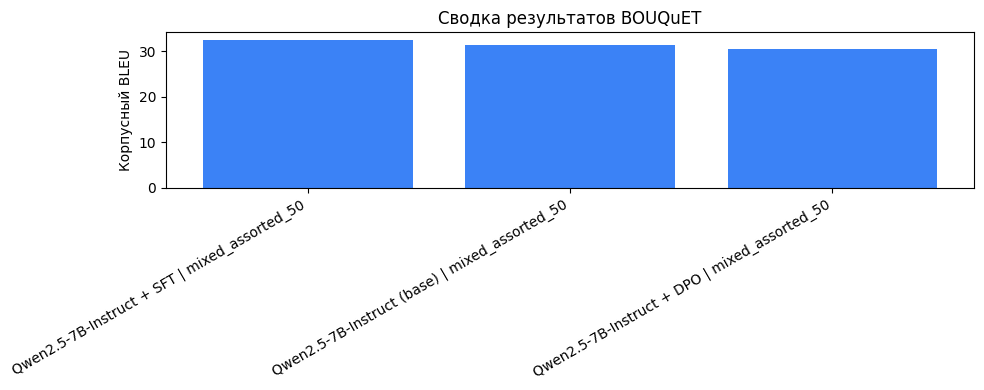

Итоговая таблица сохранена в: /content/bouquet_results/bouquet_summary.csv


In [ ]:
cleanup_loaded_objects("dpo_benchmark_model", "dpo_benchmark_tokenizer")

summary_df = pd.DataFrame(benchmark_rows)
if summary_df.empty:
    raise RuntimeError("Не найдено результатов benchmark. Сначала выполните хотя бы одну benchmark-ячейку.")

summary_df = summary_df.sort_values(
    by=["evaluation_set", "bleu", "chrf", "ter", "avg_time_sec"],
    ascending=[True, False, False, True, True],
).reset_index(drop=True)
summary_df.insert(0, "rank_overall", range(1, len(summary_df) + 1))
summary_df.insert(1, "rank_within_evaluation_set", summary_df.groupby("evaluation_set").cumcount() + 1)

summary_path = BOUQUET_RESULTS_DIR / "bouquet_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(summary_df)

plot_labels = summary_df["model"] + " | " + summary_df["evaluation_set"]
plt.figure(figsize=(max(10, len(summary_df) * 0.8), 4))
plt.bar(plot_labels, summary_df["bleu"], color="#3b82f6")
plt.ylabel("Корпусный BLEU")
plt.title("Сводка результатов BOUQuET")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Итоговая таблица сохранена в: {summary_path}")

## Итог

На данном этапе ноутбук содержит полный воспроизводимый исследовательский пайплайн: подготовку датасета, автоматическую аннотацию, двухэтапное обучение модели, быстрые качественные проверки и внешний benchmark на датасете `BOUQuET`.

Такая структура особенно удобна для дипломной работы, поскольку один файл одновременно объединяет исполняемый экспериментальный сценарий, методическое описание и итоговое сравнение моделей. Благодаря этому ноутбук можно использовать и как практический скрипт для запуска экспериментов, и как структурированную основу для письменного описания проведённого исследования.
